# Aqar Price Prediction in Riyadh
This notebook applies machine learning techniques to predict property prices in Riyadh using real estate listing data.


In [1]:
import pandas as pd

path = r"C:\Users\janah\Downloads\aqar_fm_listings.csv"

df = pd.read_csv(path)

df.head()

C:\Users\janah\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,id,title,url,price,meter_price,price_2_payments,price_4_payments,price_12_payments,rnpl_monthly_price,rent_period,...,rega_licensed,plan_no,parcel_no,user_type,user_verified,company_name,user_paid_tier,description,images,videos
0,6502998,دور للبيع في شارع شهيد الدين ثم الوطن فهد إبرا...,https://sa.aqar.fm/دور-للبيع/الرياض/شمال-الريا...,1500000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,True,3783,407 + 408,0,True,NaN,5.0,مشروع ادوار سِـــدرا مشروع يتميز بموقعه الاستر...,"['039762754_1765464943659.jpg', '039762758_176...",['039762752_1765465117982']
1,6428644,"فيلا للبيع في شارع أحمد بن حيان, حي الملقا, مد...",https://sa.aqar.fm/فلل-للبيع/الرياض/شمال-الريا...,13500000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,True,3776,177 / 2,1,True,شركة أثرى المتحدة العقارية,2.0,للبيع فيلا بتصميم مميز بملقا السلودير \n\n( ي...,"['002902001_1764757893800.jpg', '002902004_176...",[]
2,6516181,"دور للإيجار في شارع شداد بن أوس, حي العليا, مد...",https://sa.aqar.fm/دور-للإيجار/الرياض/شمال-الر...,105000.0,NaN,NaN,NaN,NaN,0.0,NaN,...,True,772,121,0,True,شركة السواعد العقارية,2.0,للإيجار فرصة سكنية مميزة\n\n🏡 نوع العقار: دور ...,"['043760574_1766388486688.jpg', '043760579_176...",['043760577_1766389086357']
3,6495984,"شقة للبيع في شارع الغائر, حي المروج, مدينة أبه...",https://sa.aqar.fm/شقق-للبيع/ابها/حي-درة-المنس...,635000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,True,1022 / 1424هـ / ع / 1,499,0,True,مكتب خيال الأركان للعقار,4.0,🏠 شقق دوبلكس نظام تاون هاوس🏠\nللبيع شقق دوبلكس...,"['000635467_1765094224978.jpg', '000635463_176...",['000635463_1765094375794']
4,6513148,"شقة للبيع في شارع السالمية, حي البحيرة, مدينة ...",https://sa.aqar.fm/شقق-للبيع/ابها/حي-ابها-الجد...,510000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,True,152 / أ / 1,17,0,True,مكتب خيال الأركان للعقار,4.0,🌟للبيع شقق تمليك في ارقى احياء ابها حي الاطلال...,"['000635468_1766167214019.jpg', '000635462_176...",['000635460_1766167341766']


In [2]:
df.select_dtypes(include='number').columns 

Index(['id', 'price', 'meter_price', 'price_2_payments', 'price_4_payments',
       'price_12_payments', 'rnpl_monthly_price', 'rent_period', 'area_sqm',
       'deed_area', 'num_bedrooms', 'num_bathrooms', 'num_living_rooms',
       'num_kitchens', 'num_rooms', 'floor_level', 'age', 'furnished',
       'duplex', 'zoning', 'ac', 'lift', 'maid_room', 'driver_room', 'pool',
       'basement', 'backyard', 'playground', 'car_entrance', 'stairs',
       'stores', 'wells', 'trees', 'street_width', 'street_direction',
       'direction_id', 'city_id', 'district_id', 'province_id', 'latitude',
       'longitude', 'create_time', 'published_at', 'last_update', 'verified',
       'boosted', 'premium', 'has_img', 'has_video', 'ad_license_number',
       'user_type', 'user_paid_tier'],
      dtype='object')

In [3]:
cols = ['area_sqm', 'price', 'num_rooms']
df_selected = df[cols]

df_selected.head()

,area_sqm,price,num_rooms
0,116,1500000.0,4.0
1,700,13500000.0,7.0
2,102,105000.0,2.0
3,215,635000.0,6.0
4,169,510000.0,5.0


[0] loss = 18516746242099.2773


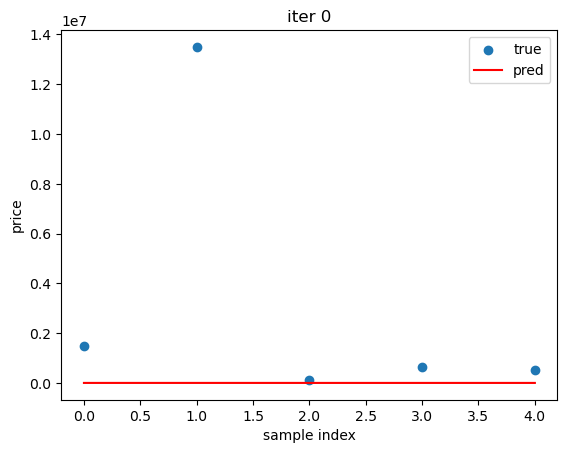

[20] loss = 17756920971084.9258


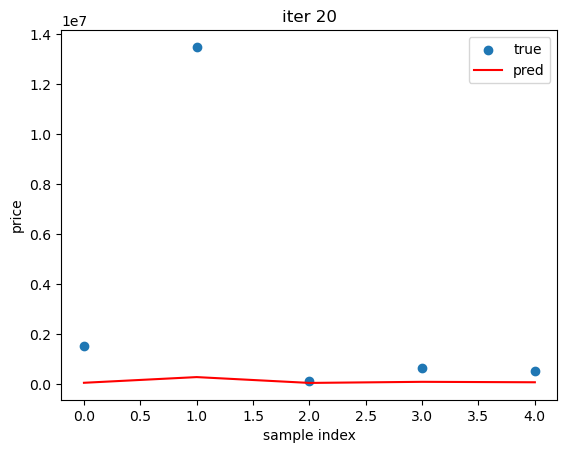

[40] loss = 17032073655512.3164


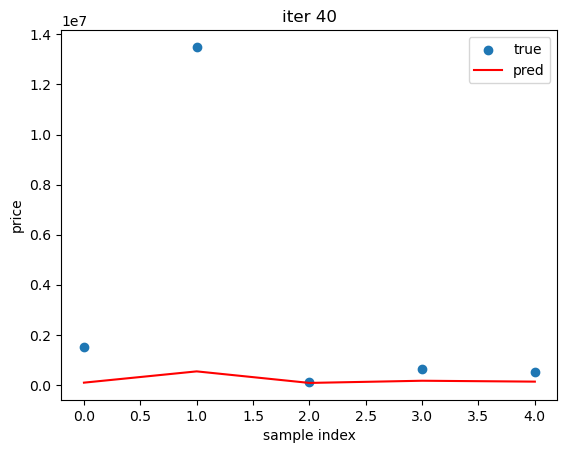

[60] loss = 16340594104190.7812


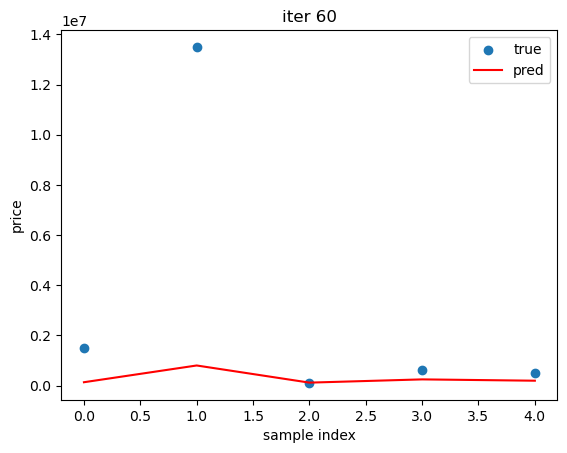

[80] loss = 15680946250207.0352


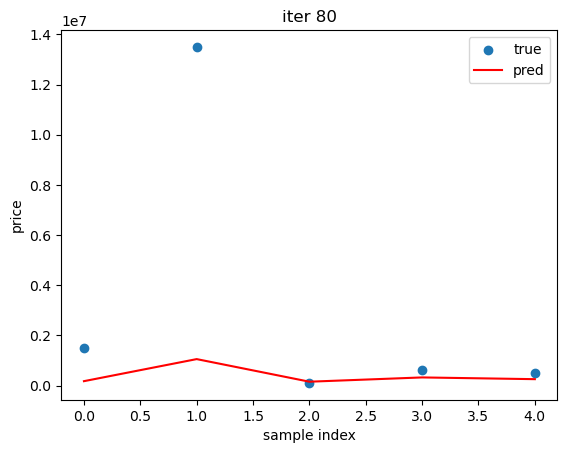

[100] loss = 15051664738654.2871


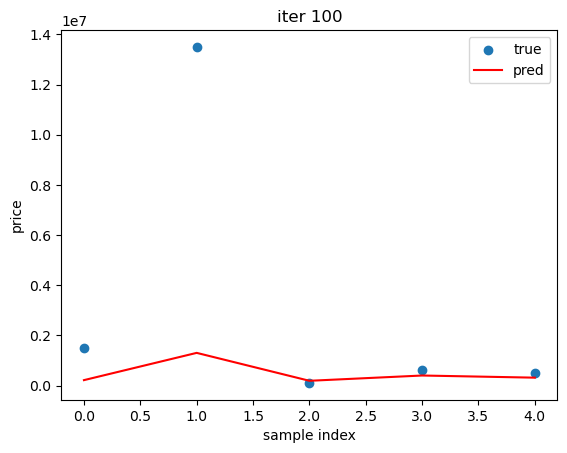

[120] loss = 14451351671443.4160


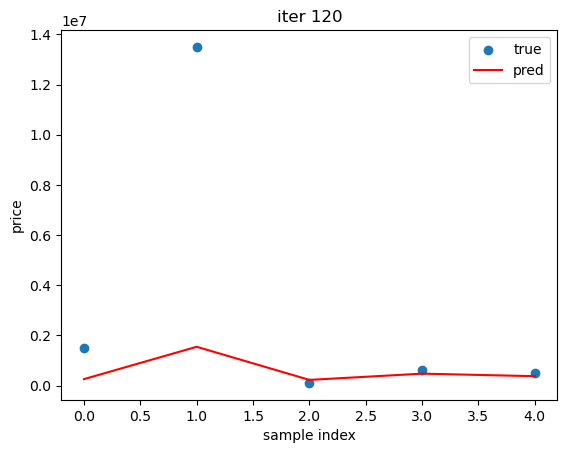

[140] loss = 13878673501965.0000


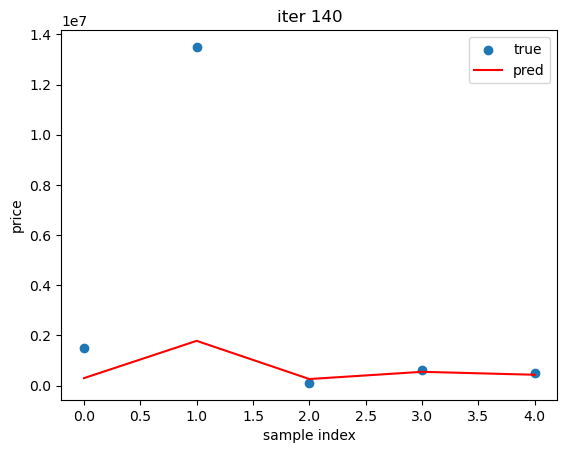

[160] loss = 13332358072703.8730


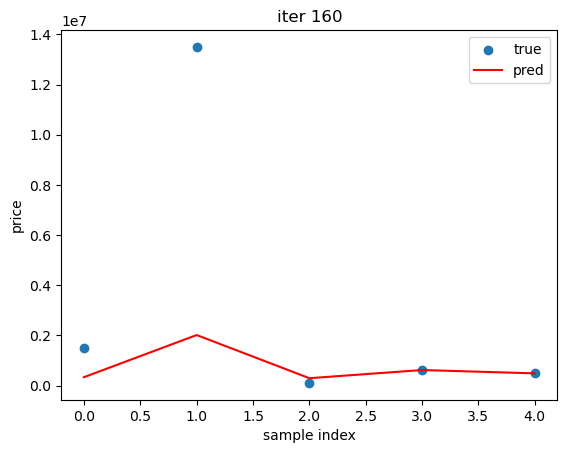

[180] loss = 12811191789225.4863


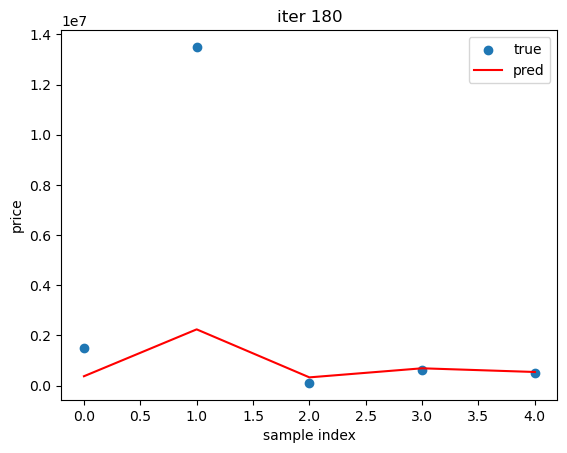

Final W: [3515.21563636   36.67076856    4.76903   ]
Final Error (0-1 scale): 0.8587


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def show_plot(y_pred, Y):
    plt.scatter(np.arange(len(Y)), Y, label="true")
    plt.plot(y_pred, label="pred", color="red")
    plt.legend()
    plt.xlabel("sample index")
    plt.ylabel("price")

def predict(W, X):
    y_pred = np.dot(X, W)
    return y_pred

def J(y_pred, Y):
    loss = 1 / 2 * (y_pred - Y)**2
    return loss

def J_gradient(y_pred, Y, X):
    j_gradients = (y_pred - Y)*X # gradients for each sample
    grad_mean = j_gradients.mean(axis=0)  # mean gradient
    return grad_mean.reshape(-1, 1)

def W_update(W_old, j_grad, alpha=1e-8):
    W_new = W_old - alpha * j_grad
    return W_new


def mean_absolute_percentage_error(Y_true, Y_pred):
    return np.abs((Y_true - Y_pred) / Y_true).mean()  # بين 0 و 1


data = {
    'area' : [116, 700, 102, 215, 169],
    'num_rooms': [4.0, 7.0, 2.0, 6.0, 5.0],
    'price' : [1500000.0, 13500000.0, 105000.0, 635000.0, 510000.0]
}

df = pd.DataFrame(data)

X = df[['area', 'num_rooms']].values
Y = np.expand_dims(df['price'].values, 1)

use_bias = True
if use_bias:
    X = np.hstack((X, np.ones((X.shape[0], 1))))

W = 2 * np.random.uniform(size=(X.shape[1], 1)) - 1


for i in range(200):
    y_pred = predict(W, X)
    loss = J(y_pred, Y).mean()
    j_grad = J_gradient(y_pred, Y, X)
    W = W_update(W, j_grad, alpha=1e-8)

    if i % 20 == 0:
        print(f"[{i}] loss = {loss:.4f}")
        show_plot(y_pred, Y)
        plt.title(f"iter {i}")
        plt.show()
        plt.close()


print("Final W:", W.reshape(-1))
final_error = mean_absolute_percentage_error(Y, y_pred)
print(f"Final Error (0-1 scale): {final_error:.4f}")
